# Module 4: Object Detection with YOLOv8

In previous lessons, we focused on **Image Classification** (assigning a single label to an entire image). **Object Detection** is a more complex task where we identify both **what** is in an image and **where** it is.

In this notebook, we'll use **YOLOv8** (You Only Look Once), a state-of-the-art model designed for real-time inference.

## Core Concepts

1.  **Bounding Box ($x, y, w, h$)**: The rectangle enclosing an object.
2.  **Confidence Score**: The model's probability that a box contains a specific object.
3.  **IoU (Intersection over Union)**: How much the predicted box overlaps with the ground truth box.
4.  **Non-Maximum Suppression (NMS)**: The process of removing redundant boxes around the same object.

```mermaid
graph TD
    Input[Input Image] --> Grid[Divide into Grid Cells]
    Grid --> Prop[Predict Bounding Boxes & Confidence]
    Prop --> Class[Predict Class Probabilities]
    Class --> NMS[Non-Maximum Suppression]
    NMS --> Final[Final Detection Box]
```

In [1]:
# Install the Ultralytics library
!pip install ultralytics -q

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Ahmad\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 1. Loading YOLOv8 Nano

The "nano" model (`yolov8n.pt`) is optimized for speed and can run on most CPUs without struggle. YOLO models are pre-trained on the **COCO** dataset (Common Objects in Context), which includes 80 classes like persons, cars, and animals.

In [2]:
model = YOLO("yolov8n.pt") 
print("Model classes:", model.names)

Model classes: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phon

## 2. Zero-Shot Inference on Local/Web Images

Let's test the model on a standard image of a busy urban scene.


0: 640x480 4 persons, 1 bus, 1 stop sign, 442.6ms
Speed: 17.5ms preprocess, 442.6ms inference, 6.1ms postprocess per image at shape (1, 3, 640, 480)


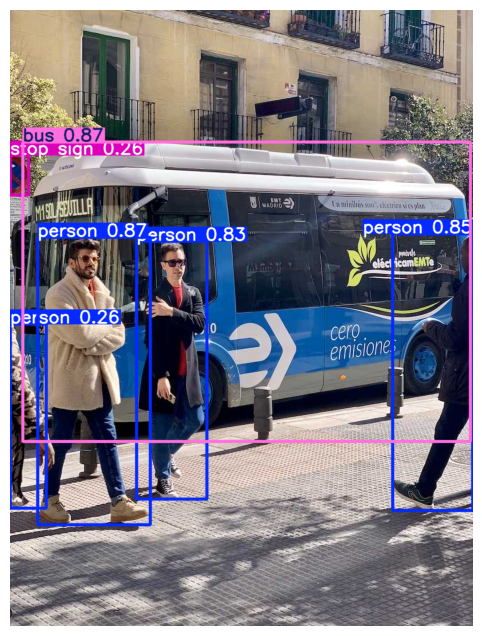

In [3]:
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Run the model
results = model(img)

# Plot the visuals
for r in results:
    res_array = r.plot() # returns BGR array
    res_img = Image.fromarray(res_array[..., ::-1]) # Convert to RGB
    plt.figure(figsize=(12, 8))
    plt.imshow(res_img)
    plt.axis('off')
    plt.show()

## 3. Extracting Structured Data

Behind the visuals, the model provides tensors with specific coordinates. This is what you would use to build an app (e.g., a security camera alert).

In [4]:
res = results[0]
print(f"Total objects found: {len(res.boxes)}")

for box in res.boxes[:5]:
    c = int(box.cls)
    conf = float(box.conf)
    xyxy = box.xyxy[0].tolist() # [xmin, ymin, xmax, ymax]
    
    print(f"{model.names[c]} detected with {conf:.2f} confidence at {xyxy}")

Total objects found: 6
bus detected with 0.87 confidence at [22.87126922607422, 231.27731323242188, 805.0026245117188, 756.8404541015625]
person detected with 0.87 confidence at [48.55046463012695, 398.55230712890625, 245.34559631347656, 902.7026977539062]
person detected with 0.85 confidence at [669.472900390625, 392.1859436035156, 809.7201538085938, 877.0354614257812]
person detected with 0.83 confidence at [221.5172882080078, 405.79864501953125, 344.9706115722656, 857.53662109375]
person detected with 0.26 confidence at [0.0, 550.5250244140625, 63.00691223144531, 873.4429321289062]


## 4. Why Use YOLO?

Historically, object detectors used two-stage processes (like R-CNN), which were accurate but very slow. YOLO redefined the field by treating detection as a **single regression problem**, determining boxes and classes in one forward pass through the network.

| Task | Input | Output |
| :--- | :--- | :--- |
| **Classification** | Image | Single Label |
| **Detection** | Image | Multi-labels + Precise Coordinates |